Epoch 0 | Train: 1.128396 | Test MSE: 2.703841
Epoch 1000 | Train: 0.149809 | Test MSE: 1.771832
Epoch 2000 | Train: 0.149692 | Test MSE: 1.744426
Epoch 3000 | Train: 0.151550 | Test MSE: 1.777409
Epoch 4000 | Train: 0.149636 | Test MSE: 1.734425
Epoch 5000 | Train: 0.149588 | Test MSE: 1.728917
Epoch 6000 | Train: 0.149530 | Test MSE: 1.725787
Epoch 7000 | Train: 0.149298 | Test MSE: 1.714071
Epoch 8000 | Train: 0.149275 | Test MSE: 1.711672
Epoch 9000 | Train: 0.147468 | Test MSE: 1.654247
Epoch 10000 | Train: 0.146471 | Test MSE: 2.153054
Epoch 11000 | Train: 0.164423 | Test MSE: 3.046606
Epoch 12000 | Train: 0.000503 | Test MSE: 0.000613
Epoch 13000 | Train: 0.000438 | Test MSE: 0.000124
Epoch 14000 | Train: 0.001270 | Test MSE: 0.000427
Epoch 15000 | Train: 0.000126 | Test MSE: 0.000173
Epoch 16000 | Train: 0.000513 | Test MSE: 0.000192
Epoch 17000 | Train: 0.003255 | Test MSE: 0.000820
Epoch 18000 | Train: 0.000379 | Test MSE: 0.000169
Epoch 19000 | Train: 0.000270 | Test MSE: 0.

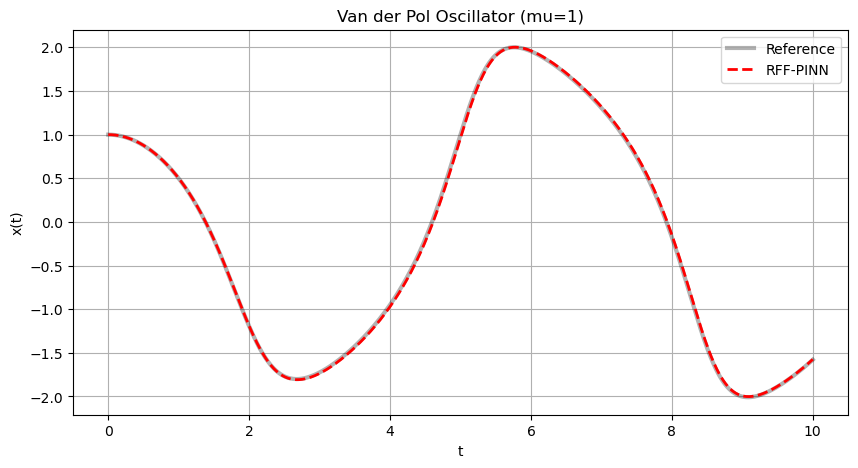

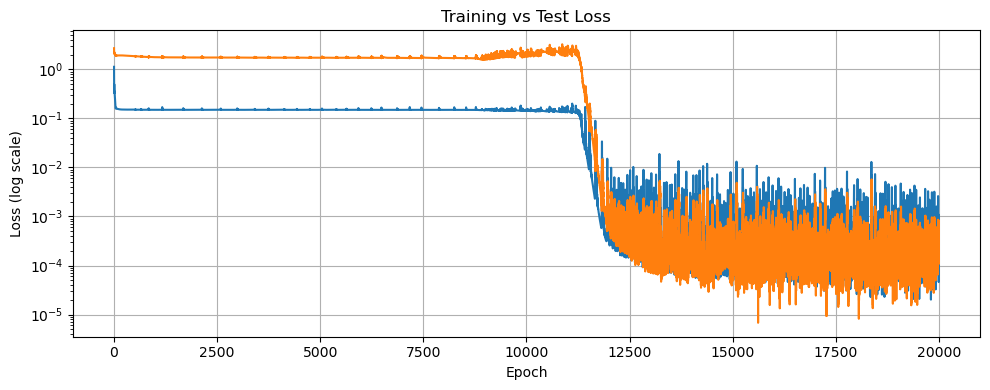

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

# -----------------------------
# 1. Neural Network
# -----------------------------
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 2. Helper functions
# -----------------------------
def d_dt(x, t):
    (dt,) = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# y bar transformation
def IVP_transform(model, t, x0, x_p0, t0):
     x_hat_t = model(t)

     x_hat_0 = model(t0)
     xp_hat_0 = d_dt(x_hat_0, t0)
     
     # x_bar
     x_bar = x_hat_t + x0 - x_hat_0 + t * (x_p0 - xp_hat_0)
     return x_bar

# -----------------------------
# 3. Training loop
# -----------------------------
def train_PINN(epochs, model, mu, t_min, t_max, x0, v0, t_test, x_test_true, n_col=1000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses = []
    test_losses = []

    # Initial time (needs grad for x'(t0))
    t0 = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

    # Collocation points like your linspace approach (fixed, deterministic)
    t_interior_np = np.linspace(t_min, t_max, n_col + 2)[1:-1]  # exclude both boundaries
    t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1, 1)
    t_interior.requires_grad_(True)

    for i in range(epochs):

        x_hat = IVP_transform(model, t_interior, x0, v0, t0)
    
        # 2) residual: y'' + y - sin(pi x)
        x_pp_hat = d2_dt2(x_hat, t_interior)
        x_p_hat = d_dt(x_hat, t_interior)
    
        r = x_pp_hat - mu * (1 - x_hat**2) * x_p_hat + x_hat

        loss = torch.mean(r**2)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        train_losses.append(loss.item())

         # ----- Test loss -----
        model.eval()
        t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
        t_test_req = t_test.clone().detach().requires_grad_(True)

        x_test_pred = IVP_transform(model, t_test_req, x0, v0, t0_eval)
        mse = torch.mean((x_test_pred - x_test_true)**2).item()

        test_losses.append(mse)
        model.train()

        if i % 1000 == 0:
            print(f"Epoch {i} | Train: {loss.item():.6f} | Test MSE: {mse:.6f}")

    return model, train_losses, test_losses

# -----------------------------
# 4. Execution
# -----------------------------
mu = 1
t_min, t_max = 0.0, 10.0
x0, v0 = 1.0, 0.0

# Reference
t_ref = np.linspace(0, 10, 1000)
sol = solve_ivp(lambda t, z: [z[1], mu*(1-z[0]**2)*z[1]-z[0]], [0, 10], [1.0, 0.0], t_eval=t_ref)
x_ref = sol.y[0]

t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)

torch.manual_seed(0)
model = BasicNetwork()
trained_model, train_loss_history, test_loss_history = train_PINN(epochs=20000, model=model, mu=mu, t_min=t_min, t_max=t_max, x0=x0, v0=v0, t_test=t_test, x_test_true=x_test_true)

# Train Model
trained_model.eval()

t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
    
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)



# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(sol.t, sol.y[0], 'k-', alpha=0.3, lw=3, label="Reference")
plt.plot(sol.t, x_pinn, 'r--', lw=2, label="RFF-PINN")
plt.title(f"Van der Pol Oscillator (mu={mu})") 
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Test (MSE vs reference)")
plt.title("Training vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Diagnostic


Training for mu = 0.1
Epoch 0 | Train: 1.127481 | Test MSE: 1.497167
Epoch 1000 | Train: 0.030344 | Test MSE: 0.399759
Epoch 2000 | Train: 0.029010 | Test MSE: 0.374900
Epoch 3000 | Train: 0.005508 | Test MSE: 0.055411
Epoch 4000 | Train: 0.000219 | Test MSE: 0.000985
Epoch 5000 | Train: 0.000050 | Test MSE: 0.000115
Epoch 6000 | Train: 0.000027 | Test MSE: 0.000055
Epoch 7000 | Train: 0.001332 | Test MSE: 0.002679
Epoch 8000 | Train: 0.000010 | Test MSE: 0.000016
Epoch 9000 | Train: 0.000013 | Test MSE: 0.000011
Epoch 10000 | Train: 0.000007 | Test MSE: 0.000011
Epoch 11000 | Train: 0.000252 | Test MSE: 0.000110
Epoch 12000 | Train: 0.000031 | Test MSE: 0.000023
Epoch 13000 | Train: 0.001127 | Test MSE: 0.001294
Epoch 14000 | Train: 0.000034 | Test MSE: 0.000024
Epoch 15000 | Train: 0.000010 | Test MSE: 0.000043
Epoch 16000 | Train: 0.000213 | Test MSE: 0.000203
Epoch 17000 | Train: 0.000214 | Test MSE: 0.000212
Epoch 18000 | Train: 0.000005 | Test MSE: 0.000014
Epoch 19000 | Train: 

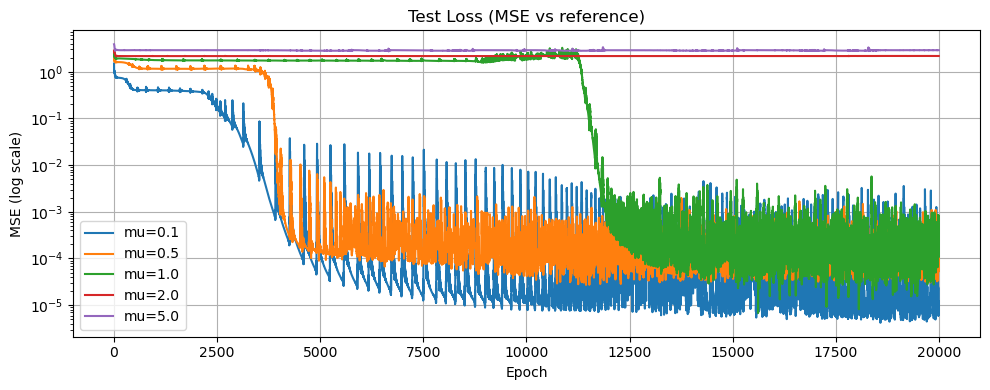

In [6]:
# -----------------------------
# Compare different w_ic values (store train + test loss)
# -----------------------------

mu_values = [0.1, 0.5, 1.0, 2.0, 5.0] 

all_train_losses = {}  # {w_ic: [train_loss over epochs]}
all_test_losses  = {}  # {w_ic: [test_mse over epochs]}

for mu in mu_values:
    print(f"\nTraining for mu = {mu}")

    
    # --- recompute reference for this mu ---
    t_ref = np.linspace(t_min, t_max, 1000)
    sol = solve_ivp(lambda t, z: [z[1], mu*(1-z[0]**2)*z[1] - z[0]],
                    [t_min, t_max], [x0, v0], t_eval=t_ref)
    x_ref = sol.y[0]

    t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
    x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)


    torch.manual_seed(0)  # same init for fair comparison
    model = BasicNetwork()

    _, train_hist, test_hist = train_PINN(epochs=20000, model=model, mu=mu, t_min=t_min, t_max=t_max,
                                          t_test=t_test, x_test_true=x_test_true, x0=x0, v0=v0, n_col=1000, lr=1e-3)

    all_train_losses[mu] = train_hist
    all_test_losses[mu]  = test_hist


# -----------------------------
# Plot: Test MSE curves for each w_ic
# -----------------------------
plt.figure(figsize=(10, 4))
for mu in mu_values:
    plt.semilogy(all_test_losses[mu], label=f"mu={mu}")
plt.title(f"Test Loss (MSE vs reference)")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

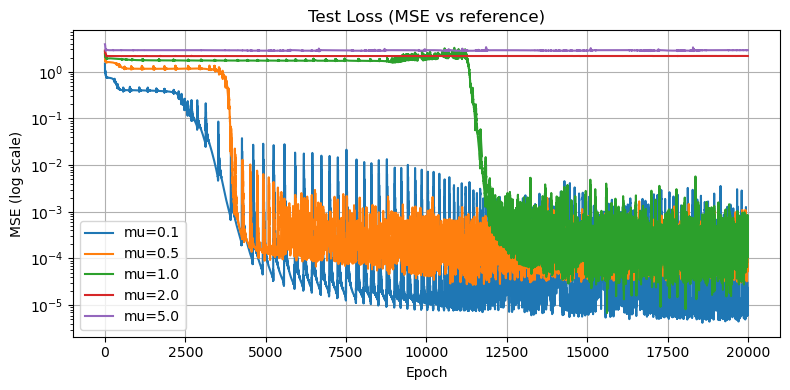

In [8]:
plt.figure(figsize=(8, 4))
for mu in mu_values:
    plt.semilogy(all_test_losses[mu], label=f"mu={mu}")
plt.title(f"Test Loss (MSE vs reference)")
plt.xlabel("Epoch")
plt.ylabel("MSE (log scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Vary_mu.png", dpi=300, bbox_inches="tight")
plt.show()

# Schedule Difference(OLD)


=== Curriculum stage 1/7: mu=0.05 for 2500 epochs (lr=0.002) ===
[mu=0.05] Epoch      0 | Train: 1.127430e+00 | Test MSE: 1.006290e+00
[mu=0.05] Epoch   1000 | Train: 2.519836e-02 | Test MSE: 2.936536e-01
[mu=0.05] Epoch   2000 | Train: 7.442786e-03 | Test MSE: 6.981876e-02

=== Curriculum stage 2/7: mu=0.1 for 2500 epochs (lr=0.002) ===
[mu=0.1] Epoch      0 | Train: 1.371285e-03 | Test MSE: 7.808000e-01
[mu=0.1] Epoch   1000 | Train: 8.278353e-06 | Test MSE: 5.023422e-07
[mu=0.1] Epoch   2000 | Train: 1.608093e-05 | Test MSE: 1.293560e-05

=== Curriculum stage 3/7: mu=0.2 for 3000 epochs (lr=0.001) ===
[mu=0.2] Epoch      0 | Train: 4.243189e-03 | Test MSE: 1.879893e-01
[mu=0.2] Epoch   1000 | Train: 1.306553e-05 | Test MSE: 3.543418e-06
[mu=0.2] Epoch   2000 | Train: 3.309539e-05 | Test MSE: 1.877388e-05

=== Curriculum stage 4/7: mu=0.5 for 3500 epochs (lr=0.001) ===
[mu=0.5] Epoch      0 | Train: 4.490892e-02 | Test MSE: 1.021426e-01
[mu=0.5] Epoch   1000 | Train: 3.368809e-05 | 

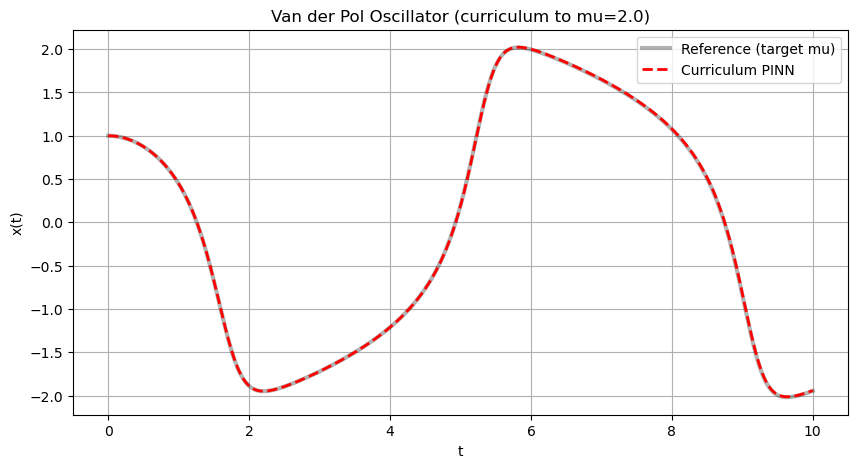

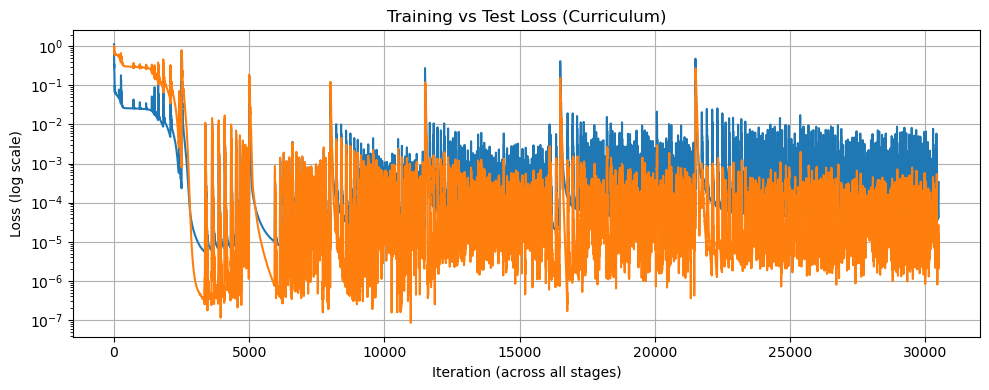

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

# -----------------------------
# 1. Neural Network
# -----------------------------
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 2. Helper functions
# -----------------------------
def d_dt(x, t):
    (dt,) = torch.autograd.grad(
        x, t, grad_outputs=torch.ones_like(x), create_graph=True
    )
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# y bar transformation enforcing x(t0)=x0 and x'(t0)=v0
def IVP_transform(model, t, x0, x_p0, t0):
    x_hat_t = model(t)

    x_hat_0 = model(t0)
    xp_hat_0 = d_dt(x_hat_0, t0)

    x_bar = x_hat_t + x0 - x_hat_0 + t * (x_p0 - xp_hat_0)
    return x_bar

# -----------------------------
# 3. Reference solver (per-mu)
# -----------------------------
def vdp_reference(mu, t_min, t_max, x0, v0, n=1000):
    t_ref = np.linspace(t_min, t_max, n)
    sol = solve_ivp(
        lambda t, z: [z[1], mu * (1 - z[0] ** 2) * z[1] - z[0]],
        [t_min, t_max],
        [x0, v0],
        t_eval=t_ref,
        rtol=1e-9,
        atol=1e-12,
    )
    x_ref = sol.y[0]
    t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
    x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)
    return sol, t_test, x_test_true

# -----------------------------
# 4. Train for a single mu (warm-start friendly)
# -----------------------------
def train_PINN_single_mu(
    epochs,
    model,
    mu,
    t_min,
    t_max,
    x0,
    v0,
    t_test,
    x_test_true,
    n_col=1000,
    lr=1e-3,
    print_every=1000,
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Initial time (needs grad for x'(t0))
    t0 = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

    # Fixed collocation points (deterministic)
    t_interior_np = np.linspace(t_min, t_max, n_col + 2)[1:-1]
    t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1, 1)
    t_interior.requires_grad_(True)

    train_losses = []
    test_losses = []

    for i in range(epochs):
        x_hat = IVP_transform(model, t_interior, x0, v0, t0)

        x_pp_hat = d2_dt2(x_hat, t_interior)
        x_p_hat = d_dt(x_hat, t_interior)

        r = x_pp_hat - mu * (1 - x_hat**2) * x_p_hat + x_hat
        loss = torch.mean(r**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        # Test
        model.eval()
        t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
        t_test_req = t_test.detach().clone().requires_grad_(True)
        x_test_pred = IVP_transform(model, t_test_req, x0, v0, t0_eval)
        mse = torch.mean((x_test_pred - x_test_true) ** 2).item()
        test_losses.append(mse)
        model.train()

        if (i % print_every) == 0:
            print(f"[mu={mu:.4g}] Epoch {i:6d} | Train: {loss.item():.6e} | Test MSE: {mse:.6e}")

    return model, train_losses, test_losses

# -----------------------------
# 5. Curriculum training wrapper
# -----------------------------
def train_PINN_curriculum(
    model,
    mu_schedule,
    epochs_schedule,
    t_min,
    t_max,
    x0,
    v0,
    n_ref=1000,
    n_col=1000,
    lr_schedule=None,
    print_every=1000,
):
    assert len(mu_schedule) == len(epochs_schedule)
    if lr_schedule is None:
        lr_schedule = [1e-3] * len(mu_schedule)
    assert len(lr_schedule) == len(mu_schedule)

    all_train = []
    all_test = []
    sols = {}

    for stage, (mu, epochs, lr) in enumerate(zip(mu_schedule, epochs_schedule, lr_schedule), start=1):
        sol, t_test, x_test_true = vdp_reference(mu, t_min, t_max, x0, v0, n=n_ref)
        sols[mu] = sol

        print(f"\n=== Curriculum stage {stage}/{len(mu_schedule)}: mu={mu} for {epochs} epochs (lr={lr}) ===")
        model, tr, te = train_PINN_single_mu(
            epochs=epochs,
            model=model,
            mu=mu,
            t_min=t_min,
            t_max=t_max,
            x0=x0,
            v0=v0,
            t_test=t_test,
            x_test_true=x_test_true,
            n_col=n_col,
            lr=lr,
            print_every=print_every,
        )
        all_train += tr
        all_test += te

    return model, all_train, all_test, sols

# -----------------------------
# 6. Execution (Curriculum)  --> TARGET MU = 2
# -----------------------------
t_min, t_max = 0.0, 10.0
x0, v0 = 1.0, 0.0
target_mu = 2.0

# Curriculum ramp to mu=2.0
mu_schedule = [0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0]
epochs_schedule = [2500, 2500, 3000, 3500, 5000, 5000, 9000]  # tweak
lr_schedule = [2e-3, 2e-3, 1e-3, 1e-3, 8e-4, 8e-4, 6e-4]      # tweak

torch.manual_seed(0)
model = BasicNetwork()

trained_model, train_loss_history, test_loss_history, sols = train_PINN_curriculum(
    model=model,
    mu_schedule=mu_schedule,
    epochs_schedule=epochs_schedule,
    lr_schedule=lr_schedule,
    t_min=t_min,
    t_max=t_max,
    x0=x0,
    v0=v0,
    n_ref=1000,
    n_col=1000,
    print_every=1000,
)

# -----------------------------
# 7. Plot against target mu reference
# -----------------------------
sol_target, _, _ = vdp_reference(target_mu, t_min, t_max, x0, v0, n=1000)

trained_model.eval()
t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)

plt.figure(figsize=(10, 5))
plt.plot(sol_target.t, sol_target.y[0], 'k-', alpha=0.3, lw=3, label="Reference (target mu)")
plt.plot(sol_target.t, x_pinn, 'r--', lw=2, label="Curriculum PINN")
plt.title(f"Van der Pol Oscillator (curriculum to mu={target_mu})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Stage Test (MSE vs stage reference)")
plt.title("Training vs Test Loss (Curriculum)")
plt.xlabel("Iteration (across all stages)")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Update Ciriculum Learning (MSE Loss)


=== Training at mu = 0.0000 ===
[mu=0.0000] Epoch     0 | [mu=0.0000] Global Epoch      0 | Train=1.127e+00 | Test MSE=1.223e+00
[mu=0.0000] Epoch   500 | [mu=0.0000] Global Epoch    500 | Train=2.222e-02 | Test MSE=2.259e-01
[mu=0.0000] Epoch  1000 | [mu=0.0000] Global Epoch   1000 | Train=2.192e-02 | Test MSE=2.217e-01
[mu=0.0000] Epoch  1500 | [mu=0.0000] Global Epoch   1500 | Train=2.138e-02 | Test MSE=2.152e-01
[mu=0.0000] Epoch  2000 | [mu=0.0000] Global Epoch   2000 | Train=2.003e-02 | Test MSE=1.973e-01
[mu=0.0000] Epoch  2500 | [mu=0.0000] Global Epoch   2500 | Train=7.779e-03 | Test MSE=6.521e-02
[mu=0.0000] Epoch  3000 | [mu=0.0000] Global Epoch   3000 | Train=4.044e-03 | Test MSE=1.588e-02
[mu=0.0000] Epoch  3500 | [mu=0.0000] Global Epoch   3500 | Train=8.838e-04 | Test MSE=5.586e-03
[mu=0.0000] Epoch  4000 | [mu=0.0000] Global Epoch   4000 | Train=5.933e-03 | Test MSE=3.768e-03
[mu=0.0000] Epoch  4500 | [mu=0.0000] Global Epoch   4500 | Train=9.888e-05 | Test MSE=2.921e-

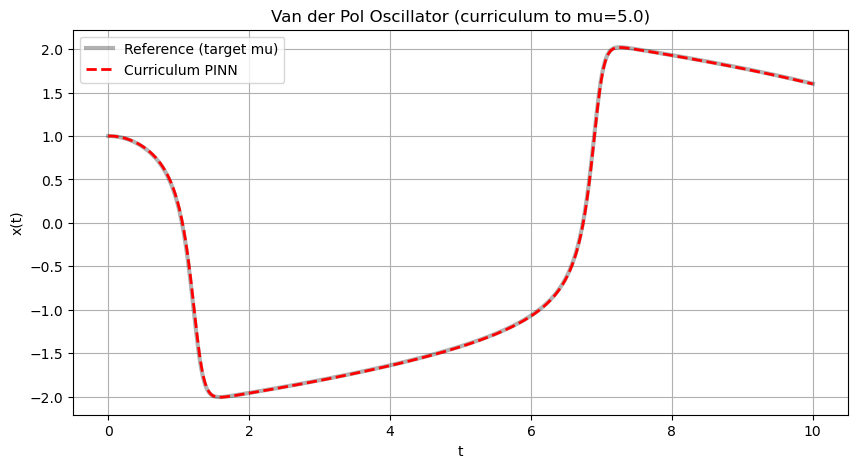

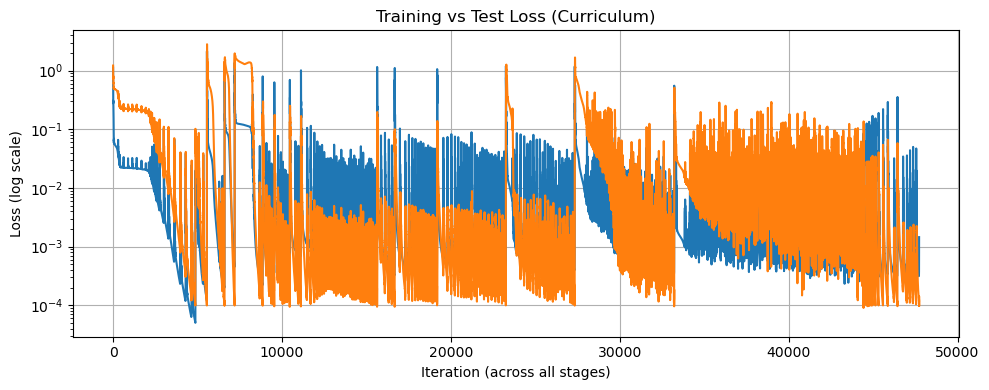

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

# -----------------------------
# 1. Neural Network
# -----------------------------
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 2. Helper functions
# -----------------------------
def d_dt(x, t):
    (dt,) = torch.autograd.grad(
        x, t, grad_outputs=torch.ones_like(x), create_graph=True
    )
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# y bar transformation enforcing x(t0)=x0 and x'(t0)=v0
def IVP_transform(model, t, x0, x_p0, t0):
    x_hat_t = model(t)

    x_hat_0 = model(t0)
    xp_hat_0 = d_dt(x_hat_0, t0)

    x_bar = x_hat_t + x0 - x_hat_0 + t * (x_p0 - xp_hat_0)
    return x_bar

# -----------------------------
# 3. Reference solver (per-mu)
# -----------------------------
def vdp_reference(mu, t_min, t_max, x0, v0, n=1000):
    t_ref = np.linspace(t_min, t_max, n)
    sol = solve_ivp(
        lambda t, z: [z[1], mu * (1 - z[0] ** 2) * z[1] - z[0]],
        [t_min, t_max],
        [x0, v0],
        t_eval=t_ref,
        rtol=1e-9,
        atol=1e-12,
    )
    x_ref = sol.y[0]
    t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
    x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)
    return sol, t_test, x_test_true

# -----------------------------
# 4. Cirriculum Training
# -----------------------------
def train_PINN_adaptive_mu(
    model,
    mu_start,
    mu_target,
    mu_step,
    mse_threshold,
    max_epochs_per_stage,
    t_min,
    t_max,
    x0,
    v0,
    lr,
    n_ref=1000,
    n_col=1000,
    print_every=500,
):
    current_mu = mu_start
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    t0 = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

    # fixed collocation grid
    t_interior_np = np.linspace(t_min, t_max, n_col + 2)[1:-1]
    t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1, 1)
    t_interior.requires_grad_(True)

    # histories across ALL stages
    train_loss_history = []
    test_loss_history = []
    mu_history = []  # track which mu each point belongs to (handy for plotting)

    global_epoch = 0
    while current_mu <= mu_target + 0.05:

        print(f"\n=== Training at mu = {current_mu:.4f} ===")

        # reference for this mu
        sol, t_test, x_test_true = vdp_reference(
            current_mu, t_min, t_max, x0, v0, n=n_ref
        )

        for epoch in range(max_epochs_per_stage):

            x_hat = IVP_transform(model, t_interior, x0, v0, t0)

            x_pp_hat = d2_dt2(x_hat, t_interior)
            x_p_hat = d_dt(x_hat, t_interior)

            r = x_pp_hat - current_mu * (1 - x_hat**2) * x_p_hat + x_hat
            loss = torch.mean(r**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ----- test MSE -----
            model.eval()
            t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
            t_test_req = t_test.detach().clone().requires_grad_(True)

            x_test_pred = IVP_transform(model, t_test_req, x0, v0, t0_eval)
            mse = torch.mean((x_test_pred - x_test_true) ** 2).item()
            model.train()

            train_loss_history.append(loss.item())
            test_loss_history.append(mse)
            mu_history.append(float(current_mu))

           

            if epoch % print_every == 0:
                print(
                    f"[mu={current_mu:.4f}] Epoch {epoch:5d} | "
                    f"[mu={current_mu:.4f}] Global Epoch {global_epoch:6d} | "
                    f"Train={loss.item():.3e} | Test MSE={mse:.3e}"
                )

            # 🔥 Adaptive switch condition
            if mse < mse_threshold:
                print(
                    f"Threshold reached at mu={current_mu:.4f} "
                    f"(MSE={mse:.2e}). Increasing mu."
                )
                break
                
            global_epoch += 1

        current_mu += mu_step

    return model, train_loss_history, test_loss_history, mu_history
    
# -----------------------------
# 6. Execution (Curriculum)  
# -----------------------------
t_min, t_max = 0.0, 10.0
x0, v0 = 1.0, 0.0
mu_start = 0.0
mu_target = 5.0
mu_step = 0.2

torch.manual_seed(0)
model = BasicNetwork()

trained_model, train_loss_history, test_loss_history, mu_history = train_PINN_adaptive_mu(
    model=model,
    mu_start=mu_start,
    mu_target=mu_target,
    mu_step=mu_step,
    mse_threshold=1e-4,    
    max_epochs_per_stage=15000,
    t_min=t_min,
    t_max=t_max,
    x0=x0,
    v0=v0,
    lr=1e-3,
)

# -----------------------------
# 7. Plot against target mu reference
# -----------------------------
sol_target, _, _ = vdp_reference(mu_target, t_min, t_max, x0, v0, n=1000)

# right before plotting
t_grid = torch.tensor(sol_target.t, dtype=torch.float32).view(-1,1)
t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

trained_model.eval()
t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)

plt.figure(figsize=(10, 5))
plt.plot(sol_target.t, sol_target.y[0], 'k-', alpha=0.3, lw=3, label="Reference (target mu)")
plt.plot(sol_target.t, x_pinn, 'r--', lw=2, label="Curriculum PINN")
plt.title(f"Van der Pol Oscillator (curriculum to mu={mu_target})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Stage Test (MSE vs stage reference)")
plt.title("Training vs Test Loss (Curriculum)")
plt.xlabel("Iteration (across all stages)")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

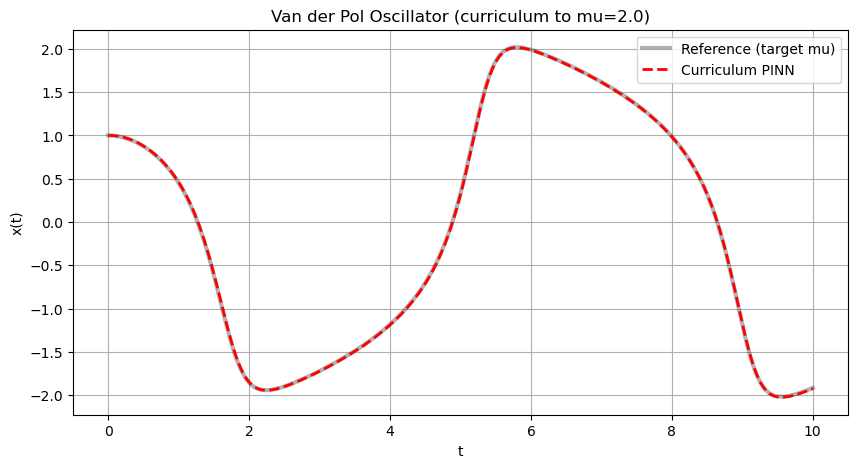

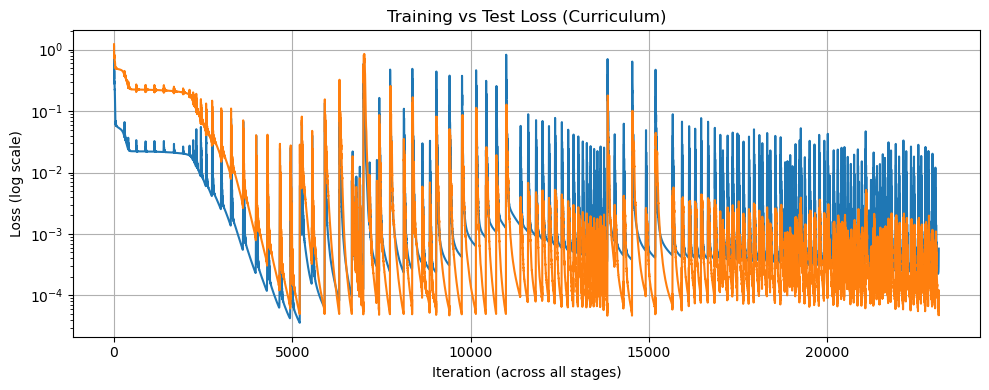

In [26]:
# -----------------------------
# 7. Plot against target mu reference
# -----------------------------
sol_target, _, _ = vdp_reference(1.9, t_min, t_max, x0, v0, n=1000)

# right before plotting
t_grid = torch.tensor(sol_target.t, dtype=torch.float32).view(-1,1)
t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

trained_model.eval()
t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)

plt.figure(figsize=(10, 5))
plt.plot(sol_target.t, sol_target.y[0], 'k-', alpha=0.3, lw=3, label="Reference (target mu)")
plt.plot(sol_target.t, x_pinn, 'r--', lw=2, label="Curriculum PINN")
plt.title(f"Van der Pol Oscillator (curriculum to mu={mu_target})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Stage Test (MSE vs stage reference)")
plt.title("Training vs Test Loss (Curriculum)")
plt.xlabel("Iteration (across all stages)")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Residual Loss

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.integrate import solve_ivp

# -----------------------------
# 1. Neural Network
# -----------------------------
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)

# -----------------------------
# 2. Helper functions
# -----------------------------
def d_dt(x, t):
    (dt,) = torch.autograd.grad(
        x, t, grad_outputs=torch.ones_like(x), create_graph=True
    )
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# y bar transformation enforcing x(t0)=x0 and x'(t0)=v0
def IVP_transform(model, t, x0, x_p0, t0):
    x_hat_t = model(t)

    x_hat_0 = model(t0)
    xp_hat_0 = d_dt(x_hat_0, t0)

    x_bar = x_hat_t + x0 - x_hat_0 + t * (x_p0 - xp_hat_0)
    return x_bar

# -----------------------------
# 3. Reference solver (per-mu)
# -----------------------------
def vdp_reference(mu, t_min, t_max, x0, v0, n=1000):
    t_ref = np.linspace(t_min, t_max, n)
    sol = solve_ivp(
        lambda t, z: [z[1], mu * (1 - z[0] ** 2) * z[1] - z[0]],
        [t_min, t_max],
        [x0, v0],
        t_eval=t_ref,
        rtol=1e-9,
        atol=1e-12,
    )
    x_ref = sol.y[0]
    t_test = torch.tensor(t_ref, dtype=torch.float32).view(-1, 1)
    x_test_true = torch.tensor(x_ref, dtype=torch.float32).view(-1, 1)
    return sol, t_test, x_test_true

# -----------------------------
# 4. Cirriculum Training
# -----------------------------
def train_PINN_adaptive_mu(
    model,
    mu_start,
    mu_target,
    mu_step,
    loss_threshold,
    max_epochs_per_stage,
    t_min,
    t_max,
    x0,
    v0,
    lr,
    n_ref=1000,
    n_col=1000,
    print_every=500,
):
    current_mu = mu_start
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    t0 = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

    # fixed collocation grid
    t_interior_np = np.linspace(t_min, t_max, n_col + 2)[1:-1]
    t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1, 1)
    t_interior.requires_grad_(True)

    # histories across ALL stages
    train_loss_history = []
    test_loss_history = []
    mu_history = []  # track which mu each point belongs to (handy for plotting

    
    global_epoch = 0
    while current_mu <= mu_target + 0.05:

        print(f"\n=== Training at mu = {current_mu:.4f} ===")

        # reference for this mu
        sol, t_test, x_test_true = vdp_reference(
            current_mu, t_min, t_max, x0, v0, n=n_ref
        )

        for epoch in range(max_epochs_per_stage):

            x_hat = IVP_transform(model, t_interior, x0, v0, t0)

            x_pp_hat = d2_dt2(x_hat, t_interior)
            x_p_hat = d_dt(x_hat, t_interior)

            r = x_pp_hat - current_mu * (1 - x_hat**2) * x_p_hat + x_hat
            loss = torch.mean(r**2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # ----- test MSE -----
            model.eval()
            t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
            t_test_req = t_test.detach().clone().requires_grad_(True)

            x_test_pred = IVP_transform(model, t_test_req, x0, v0, t0_eval)
            mse = torch.mean((x_test_pred - x_test_true) ** 2).item()
            model.train()

            train_loss_history.append(loss.item())
            test_loss_history.append(mse)
            mu_history.append(float(current_mu))

           

            if epoch % print_every == 0:
                print(
                    f"[mu={current_mu:.4f}] Epoch {epoch:5d} | "
                    f"[mu={current_mu:.4f}] Global Epoch {global_epoch:6d} | "
                    f"Train={loss.item():.3e} | Test MSE={mse:.3e}"
                )

            # 🔥 Adaptive switch condition
            if loss.item() < loss_threshold:
                print(
                    f"Threshold reached at mu={current_mu:.4f} "
                    f"(MSE={mse:.2e}). Increasing mu."
                )
                break
                
            global_epoch += 1

        current_mu += mu_step

    return model, train_loss_history, test_loss_history, mu_history
    
# -----------------------------
# 6. Execution (Curriculum)  
# -----------------------------
t_min, t_max = 0.0, 10.0
x0, v0 = 1.0, 0.0
mu_start = 0.0
mu_target = 5.0
mu_step = 0.1

torch.manual_seed(0)
model = BasicNetwork()

trained_model, train_loss_history, test_loss_history, mu_history = train_PINN_adaptive_mu(
    model=model,
    mu_start=mu_start,
    mu_target=mu_target,
    mu_step=mu_step,
    #mse_threshold=1e-4,    
    loss_threshold=5e-4,
    max_epochs_per_stage=15000,
    t_min=t_min,
    t_max=t_max,
    x0=x0,
    v0=v0,
    lr=1e-3,
)

# -----------------------------
# 7. Plot against target mu reference
# -----------------------------
sol_target, _, _ = vdp_reference(mu_target, t_min, t_max, x0, v0, n=1000)

# right before plotting
t_grid = torch.tensor(sol_target.t, dtype=torch.float32).view(-1,1)
t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

trained_model.eval()
t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)

plt.figure(figsize=(10, 5))
plt.plot(sol_target.t, sol_target.y[0], 'k-', alpha=0.3, lw=3, label="Reference (target mu)")
plt.plot(sol_target.t, x_pinn, 'r--', lw=2, label="Curriculum PINN")
plt.title(f"Van der Pol Oscillator (curriculum to mu={mu_target})")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Stage Test (MSE vs stage reference)")
plt.title("Training vs Test Loss (Curriculum)")
plt.xlabel("Iteration (across all stages)")
plt.ylabel("Loss (log scale)")
plt.grid(True)
plt.tight_layout()
plt.show()


=== Training at mu = 0.0000 ===
[mu=0.0000] Epoch     0 | [mu=0.0000] Global Epoch      0 | Train=1.127e+00 | Test MSE=1.223e+00
[mu=0.0000] Epoch   500 | [mu=0.0000] Global Epoch    500 | Train=2.222e-02 | Test MSE=2.259e-01
[mu=0.0000] Epoch  1000 | [mu=0.0000] Global Epoch   1000 | Train=2.192e-02 | Test MSE=2.217e-01


KeyboardInterrupt: 

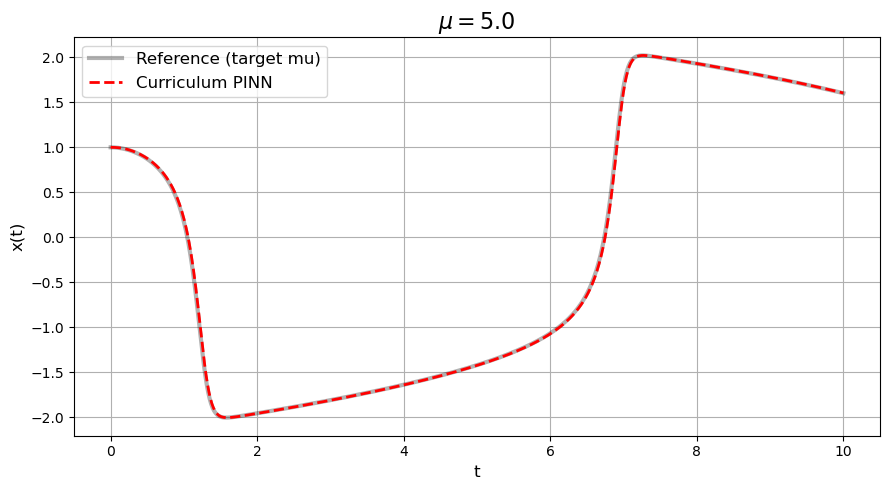

In [24]:
# -----------------------------
# 7. Plot against target mu reference
# -----------------------------
sol_target, _, _ = vdp_reference(mu_target, t_min, t_max, x0, v0, n=1000)

# right before plotting
t_grid = torch.tensor(sol_target.t, dtype=torch.float32).view(-1,1)
t0_eval = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)

trained_model.eval()
t_plot = torch.linspace(t_min, t_max, 1000).reshape(-1, 1).requires_grad_(True)
t0_plot = torch.tensor([[t_min]], dtype=torch.float32, requires_grad=True)
x_pinn = IVP_transform(trained_model, t_plot, x0, v0, t0_plot).detach().numpy().reshape(-1)

plt.figure(figsize=(9,5))
plt.plot(sol_target.t, sol_target.y[0], 'k-', alpha=0.3, lw=3, label="Reference (target mu)")
plt.plot(sol_target.t, x_pinn, 'r--', lw=2, label="Curriculum PINN")
plt.title(rf"$\mu = {mu_target}$", fontsize=16)
plt.xlabel("t", fontsize=12)
plt.ylabel("x(t)", fontsize=12)
plt.legend( fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("mew=5_plot.png", dpi=300, bbox_inches="tight")  # saves figure
plt.show()


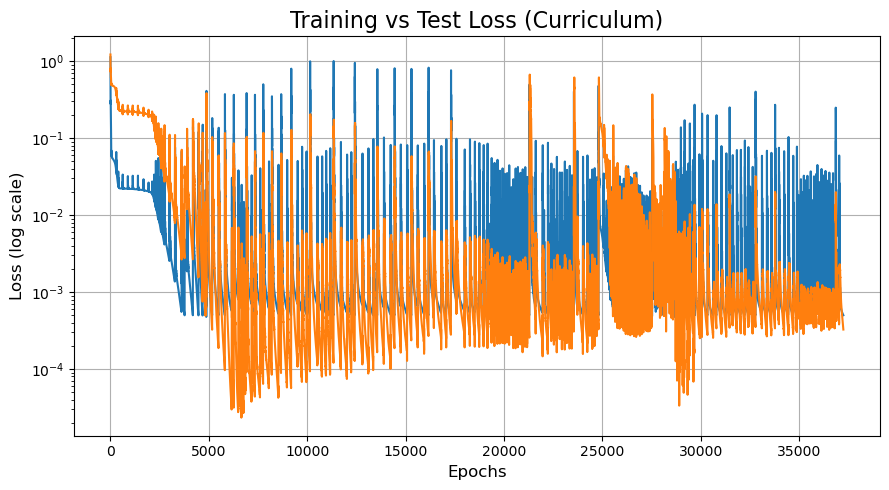

In [25]:
plt.figure(figsize=(9,5))
plt.semilogy(train_loss_history, label="Train (physics residual)")
plt.semilogy(test_loss_history, label="Stage Test (MSE vs stage reference)")
plt.title("Training vs Test Loss (Curriculum)", fontsize=16)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Loss (log scale)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("mew=5_loss_graph.png", dpi=300, bbox_inches="tight")  # saves figure
plt.show()